In [1]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from flax import nnx
from functools import partial
import time
import jax
import jax.numpy as jnp
import netket as nk
import optax
from scipy.sparse.linalg import eigsh
from jax import flatten_util
import pickle
import sys
sys.path.append('../')
from H2_631G import SINGLE_SIZE, ha, hi_ext, ext_edges, K, Hatree_Fock,hi,E_fcis,hi,single_rule,g,hf_ground_energy
import logging

jax.config.update("jax_enable_x64", True)

/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: You must cite NetKet according to our policy. Use nk.cite() to find out how.

H2 分子基本信息
HF energy = -0.99749729 Ha
Total electrons = (1, 1)
Total basis functions = 4
H₂ FCI 基准能量
E0 = -1.05434745 Ha  |  激发能: 0.0000 eV
E1 = -0.95790573 Ha  |  激发能: 2.6243 eV
E2 = -0.66895227 Ha  |  激发能: 10.4871 eV
E3 = -0.55140192 Ha  |  激发能: 13.6859 eV
E4 = -0.02803278 Ha  |  激发能: 27.9275 eV
E5 = -0.01450343 Ha  |  激发能: 28.2956 eV
E6 = -0.00518297 Ha  |  激发能: 28.5492 eV
E7 = 0.02397075 Ha  |  激发能: 29.3425 eV
E8 = 0.23432390 Ha  |  激发能: 35.0666 eV
E9 = 0.25720575 Ha  |  激发能: 35.6892 eV
E10 = 0.49958128 Ha  |  激发能: 42.2846 eV
E11 = 0.50024484 Ha  |  激发能: 42.3026 eV

HF reference state: [0 0 0 1 0 0 0 1]
single_edges: [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3), (4, 5), (4, 6), (4, 7), (5, 6), (5, 7), (6, 7)]


In [7]:
def quantum_neural_network(x, params, n_qubits, n_layers):
    """
    兼容Batch的量子电路核心逻辑
    - x: 输入张量，形状为 (batch_size, n_qubits)
    - params: 量子电路参数，形状为 (n_layers, 2 * n_qubits)
    """
    x = jnp.atleast_2d(x)
    if x.shape[-1] != n_qubits:
        raise ValueError(f"输入特征维度需为{n_qubits}，当前为{x.shape[-1]}")
    
    # 数据编码：向量化RX门
    for i in range(n_qubits):
        qml.RX(x[:, i] * jnp.pi, wires=i)
    qml.Barrier(wires=range(n_qubits))
    
    # 变分层：向量化旋转/纠缠门
    for layer in range(n_layers):
        # 纠缠层（CNOT无参数，Batch不影响）
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
        qml.Barrier(wires=range(n_qubits))
        # 旋转层：参数向量化，自动适配Batch
        for i in range(n_qubits):
            qml.RX(params[layer, 2*i], wires=i)
            qml.RZ(params[layer, 2*i+1], wires=i)
    
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

def qnn_circuit(n_qubits: int, n_layers: int):
    dev = qml.device('default.qubit', wires=n_qubits)
    pqc_node = qml.QNode(func=quantum_neural_network, device=dev, interface='jax')
    qnn_node_circuit = partial(pqc_node, n_qubits=n_qubits, n_layers=n_layers)
    return qnn_node_circuit

class QNNLinear(nnx.Module):
    def __init__(self, rngs: nnx.Rngs, n_qubits: int, n_layer: int):
        key = rngs.params()
        self.n_qubits, self.n_layer = n_qubits, n_layer
        self.qnn_params = nnx.Param(jax.random.normal(key, (self.n_layer, 2*self.n_qubits), dtype=jnp.float32))
        self.qnn_layer = partial(qnn_circuit, n_qubits=self.n_qubits, n_layers=self.n_layer)()
        self.Linear = nnx.Linear(in_features=self.n_qubits, out_features=self.n_qubits, use_bias=False, rngs=rngs)
        
    def __call__(self, s: np.array):
        s = jnp.array(s, dtype=jnp.float32)
        qnn_output = self.qnn_layer(x=s, params=self.qnn_params)
        qnn_output = jnp.stack(qnn_output, axis=1)
        qnn_output = jnp.array(qnn_output, dtype=jnp.float32)
        y = self.Linear(qnn_output)
        y = nnx.relu(y)
        return jnp.sum(y, axis=-1)

class QNN_Hybrid(nnx.Module):
    def __init__(self, rngs_real: nnx.Rngs, rngs_imag: nnx.Rngs, n_qubits: int, n_layer: int):
        self.qnn_real = QNNLinear(rngs_real, n_qubits, n_layer)
        self.qnn_imag = QNNLinear(rngs_imag, n_qubits, n_layer)
        
    def __call__(self, s: np.array):
        real = self.qnn_real(s)
        imag = self.qnn_imag(s)
        return real + 1j*imag
    

In [8]:
def initialize_parameters(n_layers, n_qubits):
    """初始化量子神经网络参数
    
    Args:
        n_layers (int): 变分层数量
        n_qubits (int): 量子比特数量
        
    Returns:
        array: 初始化的参数
    """
    # 每个变分层有3*n_qubits个参数（每个量子比特有RX, RY, RZ三个旋转门）
    params_shape = (n_layers, 2 * n_qubits)
    return np.random.uniform(0, 2*np.pi, size=params_shape)

## PQC可视化

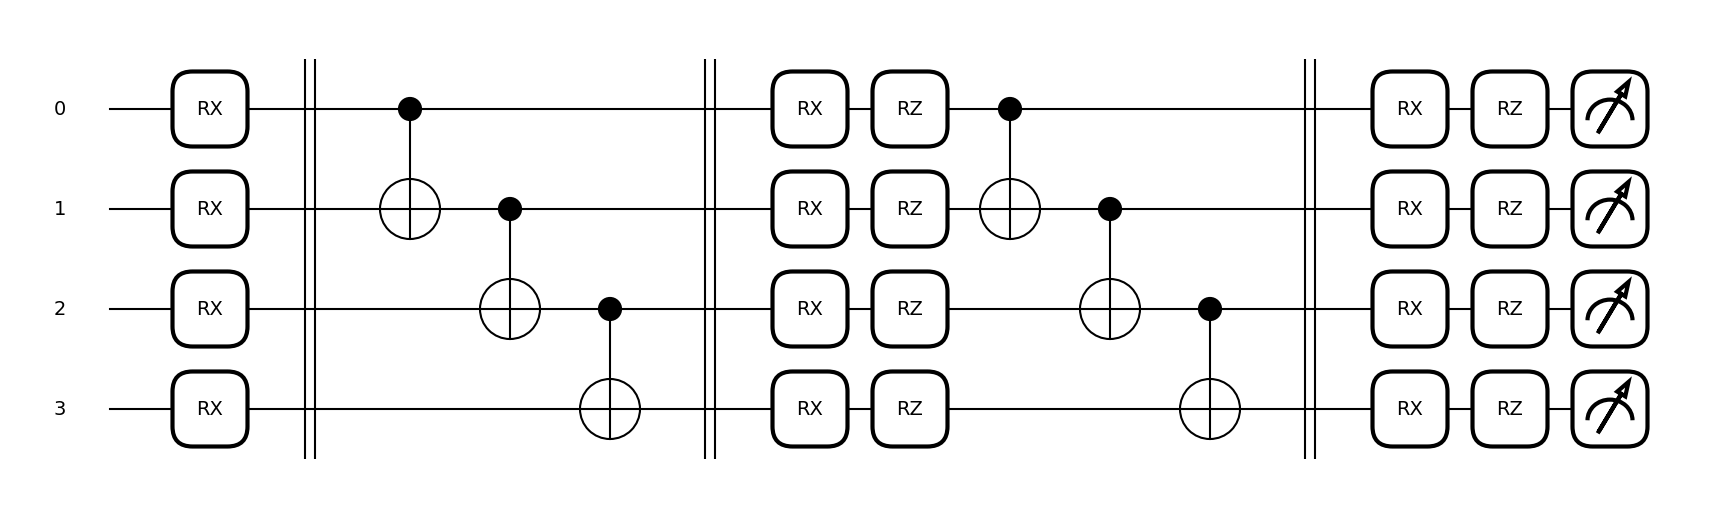

In [9]:
import matplotlib.pyplot as plt
n_qubits = 4
n_layers = 2
dev = qml.device("default.qubit", wires=n_qubits)
# 封装QNode：interface="jax" 确保兼容JAX/NNX的Batch计算
qnode = qml.QNode(quantum_neural_network, dev, interface="jax")
qml.drawer.use_style("black_white")
fig, ax = qml.draw_mpl(qnode)(x=[1,0,1,0],params=initialize_parameters(2,4),n_layers=2,n_qubits=4)
plt.show()

In [ ]:

def create_machine(model: nnx.Module):
    """将 Flax NNX 模型包装为 machine 函数"""
    graphdef, state = nnx.split(model)

    @jax.jit
    def machine(params, sigma):
        m = nnx.merge(graphdef, params)
        return m(sigma)

    return machine, graphdef, state


# ===================== 局部能量 =====================
@partial(jax.jit, static_argnames=("machine",))
def compute_local_energies(machine, params, sigma):
    eta, H_eta = ha.get_conn_padded(sigma)
    logpsi_sigma = machine(params, sigma)
    logpsi_eta = machine(params, eta)
    logpsi_sigma = jnp.expand_dims(logpsi_sigma, -1)
    return jnp.sum(H_eta * jnp.exp(logpsi_eta - logpsi_sigma), axis=-1)


# ===================== 每样本梯度：实参数网络，拆实部/虚部求导 =====================
def _grad_logpsi_real_params(machine, params, sigma):
    """
    实参数、复输出的 logψ 梯度：
        ∇ logψ(σ) = ∇ Re logψ(σ) + i · ∇ Im logψ(σ)
    （这就是 holomorphic=False 时手写的正确版本，绕开 jax.grad 的实输出限制）
    """
    re_grad = jax.vmap(
        lambda s: jax.grad(lambda p: machine(p, s).real)(params)
    )(sigma)
    im_grad = jax.vmap(
        lambda s: jax.grad(lambda p: machine(p, s).imag)(params)
    )(sigma)
    return jax.tree_util.tree_map(lambda r, i: r + 1j * i, re_grad, im_grad)


# ===================== 重要性加权（配合 machine_pow=1 采样 p ∝ |ψ|） =====================
# 动机：按 |ψ|² 采样时，一旦 |ψ|² 塌缩到单个组态（如 HF），梯度信号 ∝ ψη 的激发组态
# 永远采不到 → force 梯度恒 0 → 冻结在本征态。改按 |ψ| 采样并对估计器加权
# w(σ) = |ψσ|²/p(σ) ∝ |ψσ|，稀有组态访问率提升数个量级，其 w·E_loc·∇logψ 贡献
# 恰好恢复精确公式（w·E_loc ~ ψη·H 为有限量），这是通用的重要性加权 VMC。

@partial(jax.jit, static_argnames=("machine",))
def _sample_weights(machine, params, sigma):
    """w_i = |ψ(σ_i)|（未归一化），配合 p ∝ |ψ| 的采样分布"""
    logpsi = machine(params, sigma)
    return jnp.exp(jnp.real(logpsi))


def _weighted_mean_std(x, w):
    w_sum = jnp.sum(w)
    mean = jnp.sum(w * x) / w_sum
    var = jnp.sum(w * jnp.abs(x - mean) ** 2) / w_sum
    return mean, jnp.sqrt(var / x.shape[0])


@partial(jax.jit, static_argnames=("machine",))
def forces_expect_hermitian(machine, params, sigma):
    """
    重要性加权 force 梯度（实参数网络，取实部）：
        ∇⟨E⟩ = 2·Re⟨(E_loc − ⟨E⟩) (∇log ψ)*⟩_w
    E 是实参数的实值函数，梯度必须为实数；复数中间量只保留实部。
    返回的 grad 已含因子 2（即完整 ∇⟨E⟩）。
    """
    w = _sample_weights(machine, params, sigma)
    O_loc = compute_local_energies(machine, params, sigma)
    O_mean, O_std = _weighted_mean_std(O_loc, w)
    O_centered = O_loc - O_mean

    grad_matrix = _grad_logpsi_real_params(machine, params, sigma)

    def weight_and_mean(grad_component):
        wc = (w * O_centered).reshape((w.shape[0],) + (1,) * (grad_component.ndim - 1))
        return (jnp.sum(wc * jnp.conj(grad_component), axis=0) / jnp.sum(w)).real

    grad = jax.tree_util.tree_map(weight_and_mean, grad_matrix)
    return O_mean, O_std, grad


def compute_qgt(machine, params, sigma, diag_shift=0.1):
    """
    加权 QGT / F 矩阵（实参数网络，取实部）。
    实参数位移 dθ 为实向量时 ⟨|dlogψ|²⟩ = dθᵀ Re(S) dθ，
    虚部是反对称部分、对实二次型无贡献，度量取 Re(S)。
    """
    n_samples = sigma.shape[0]
    w = _sample_weights(machine, params, sigma)
    grad_matrix = _grad_logpsi_real_params(machine, params, sigma)
    grad_flat, unravel_fn = flatten_util.ravel_pytree(grad_matrix)
    grad_flat = grad_flat.reshape(n_samples, -1)
    w_mean = jnp.sum(w[:, None] * grad_flat, axis=0, keepdims=True) / jnp.sum(w)
    grad_centered = grad_flat - w_mean
    qw = (w[:, None] * jnp.conj(grad_centered)).T @ grad_centered / jnp.sum(w)
    qgt = qw.real  # 实参数度量
    qgt_reg = qgt + diag_shift * jnp.eye(qgt.shape[0])
    return qgt_reg, unravel_fn


In [ ]:

learning_rate = 0.1
diag_shift = 0.01
seed = 21

model = SingleStateAnsatz_SharedBackbone(
    n_spin_orbitals=SINGLE_SIZE, hidden_dim=SINGLE_SIZE * 2 + 4, rngs=nnx.Rngs(seed)
)
# machine_pow=1: 按 |ψ|（而非 |ψ|²）采样，配合重要性加权估计器，
# 避免波函数塌缩后梯度信号丢失（见 _sample_weights 注释）
sampler = nk.sampler.MetropolisSampler(
    hi, rule=single_rule, n_chains=150, sweep_size=32, machine_pow=1
)
machine, graphdef, params = create_machine(model)
sampler_state = sampler.init_state(machine, params, seed=1)

optimizer = optax.sgd(learning_rate=learning_rate)
opt_state = optimizer.init(params)

n_iter = 400

history = {'step': [], 'energy': [], 'energy_std': [], 'error': []}

print("\n" + "=" * 60)
print("开始纯 JAX VMC 训练 (自然梯度下降法, 重要性加权)")
print("=" * 60)

samples = None
t0 = time.time()
for step in range(n_iter):
    sampler_state = sampler.reset(machine, params, sampler_state)
    samples, sampler_state = sampler.sample(
        machine, params, state=sampler_state, chain_length=20
    )
    samples = samples.reshape(-1, hi.size)

    # 1. force-based 能量和梯度（grad 已是完整 ∇⟨E⟩，实数）
    energy, energy_std, grad = forces_expect_hermitian(machine, params, samples)

    # 2. 自然梯度 = S^{-1} * grad
    qgt_reg, _ = compute_qgt(machine, params, samples, diag_shift=diag_shift)
    grad_flat, grad_unravel_fn = flatten_util.ravel_pytree(grad)
    natural_grad = jnp.linalg.solve(qgt_reg, grad_flat)
    grad = grad_unravel_fn(natural_grad)

    # 3. 更新参数
    updates, opt_state = optimizer.update(grad, opt_state, params)
    params = optax.apply_updates(params, updates)

    # 4. 记录历史
    if step % 50 == 0 or step == n_iter - 1:
        error = jnp.abs(energy.real - E_fcis[0])
        history['step'].append(step)
        history['energy'].append(float(energy.real))
        history['energy_std'].append(float(energy_std))
        history['error'].append(float(error))
        print(
            f"Step {step:3d} | E: {energy.real:.8f} ± {energy_std:.6f} "
            f"| FCI: {E_fcis[0]:.8f} | Error: {error:.6f}"
        )

# 最终结果
final_energy, final_std, _ = forces_expect_hermitian(machine, params, samples)
final_error = jnp.abs(final_energy.real - E_fcis[0])
print("\n" + "=" * 60)
print(f"训练完成! 用时 {time.time() - t0:.1f}s")
print(f"最终能量：{final_energy.real:.8f} ± {final_std:.6f} Ha")
print(f"FCI 基准：{E_fcis[0]:.8f} Ha")
print(f"绝对误差：{final_error:.6f} Ha")
print(f"相对误差：{final_error / jnp.abs(E_fcis[0]) * 100:.4f}%")
print("=" * 60)


In [ ]:

# 绘图
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(history['step'], history['energy'], yerr=history['energy_std'],
            fmt='o-', capsize=3, label='VMC energy')
ax.axhline(E_fcis[0], color='r', ls='--', label=f'FCI E0 = {E_fcis[0]:.6f} Ha')
ax.axhline(hf_ground_energy, color='g', ls='--', label=f'HF energy = {hf_ground_energy:.6f} Ha')
ax.set_xlabel('iteration')
ax.set_ylabel('Energy (Ha)')
ax.set_title('FFNN amplitude-phase VMC (H2/6-31G)')
ax.legend()
fig.tight_layout()
out_png = 'FFNN振幅相位分离版-VMC-1.png'
fig.savefig(out_png, dpi=150)
print(f"训练曲线已保存: {out_png}")
